#  Revenue Leakage Analysis using Python

##  Objective
This project analyzes retail sales data to identify revenue leakage caused by high discounts and low profitability.  
We use Python to clean data, engineer features, detect risk patterns, and generate business insights.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("C:/Users/surek/OneDrive/Desktop/revenue_leakage_dataset.csv")
df.head()

,Order_ID,Order_Date,Product_Name,Category,Region,Sales,Discount,Profit,Cost
0,1001,2024-01-01,Smartphone,Furniture,East,24150,0.20,4830.0000,19320.0000
1,1002,2024-01-02,Monitor,Technology,West,3711,0.42,538.0950,3172.9050
2,1003,2024-01-03,Tablet,Furniture,Central,5853,0.09,1331.5575,4521.4425
3,1004,2024-01-04,Office Table,Furniture,South,30077,0.45,4135.5875,25941.4125
4,1005,2024-01-05,Smartphone,Technology,South,24863,0.30,4351.0250,20511.9750


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      500 non-null    int64  
 1   Order_Date    500 non-null    object 
 2   Product_Name  500 non-null    object 
 3   Category      500 non-null    object 
 4   Region        500 non-null    object 
 5   Sales         500 non-null    int64  
 6   Discount      500 non-null    float64
 7   Profit        500 non-null    float64
 8   Cost          500 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 35.3+ KB


,Order_ID,Sales,Discount,Profit,Cost
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,25525.426000,0.275180,4615.512645,20909.913355
std,144.481833,14027.211557,0.130139,2717.416582,11522.903546
min,1001.000000,1060.000000,0.050000,174.900000,885.100000
25%,1125.750000,13236.000000,0.160000,2255.165625,11036.653125
50%,1250.500000,25576.000000,0.280000,4441.970000,20951.910000
75%,1375.250000,37077.500000,0.380000,6523.258125,30218.949375
max,1500.000000,49988.000000,0.500000,11477.230000,42318.950000


In [6]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Product_Name    0
Category        0
Region          0
Sales           0
Discount        0
Profit          0
Cost            0
dtype: int64

In [15]:
df = df.drop_duplicates()

print("Duplicates Removed")

Duplicates Removed


In [16]:
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100


df["Revenue_Efficiency"] = df["Profit"] / df["Sales"]


df["Expected_Profit"] = df["Sales"] * 0.20


df["Revenue_Leakage"] = df["Expected_Profit"] - df["Profit"]

print("Feature Engineering Completed")

Feature Engineering Completed


In [17]:
df["Risk_Flag"] = np.where(
    (df["Discount"] > 0.30) & (df["Profit_Margin"] < 10),
    "High Risk",
    "Normal"
)

df["Risk_Flag"].value_counts()

Risk_Flag
Normal    500
Name: count, dtype: int64

In [18]:
category_analysis = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Revenue_Leakage": "sum",
    "Discount": "mean"
}).reset_index()

category_analysis

,Category,Sales,Profit,Revenue_Leakage,Discount
0,Furniture,4352736,784776.0875,85771.1125,0.273220
1,Office Supplies,4177798,764928.6425,70630.9575,0.270191
2,Technology,4232179,758051.5925,88384.2075,0.281988


In [19]:
region_analysis = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Revenue_Leakage": "sum"
}).reset_index()

region_analysis

,Region,Sales,Profit,Revenue_Leakage
0,Central,2777263,507210.2775,48242.3225
1,East,3344029,619977.9575,48827.8425
2,South,3533086,632005.8100,74611.3900
3,West,3108335,548562.2775,73104.7225


In [20]:
product_analysis = df.groupby("Product_Name").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Revenue_Leakage": "sum"
}).reset_index()

product_analysis.sort_values(
    by="Revenue_Leakage",
    ascending=False
).head(10)

,Product_Name,Sales,Profit,Revenue_Leakage
5,Mouse,1474912,252966.1075,42016.2925
8,Smartphone,1498213,266525.0950,33117.5050
2,Keyboard,1069868,182453.7225,31519.8775
0,Desk Chair,1445766,261485.6975,27667.5025
9,Tablet,1322090,240872.3450,23545.6550
7,Printer,1100013,197721.0150,22281.5850
3,Laptop,1453486,272977.1850,17720.0150
1,Headphones,1068694,197746.5350,15992.2650
6,Office Table,1306255,245480.5225,15770.4775
4,Monitor,1023416,189528.0975,15155.1025


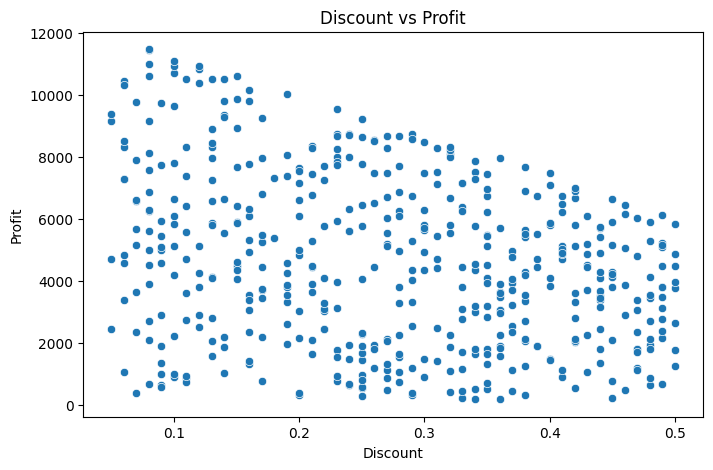

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.show()

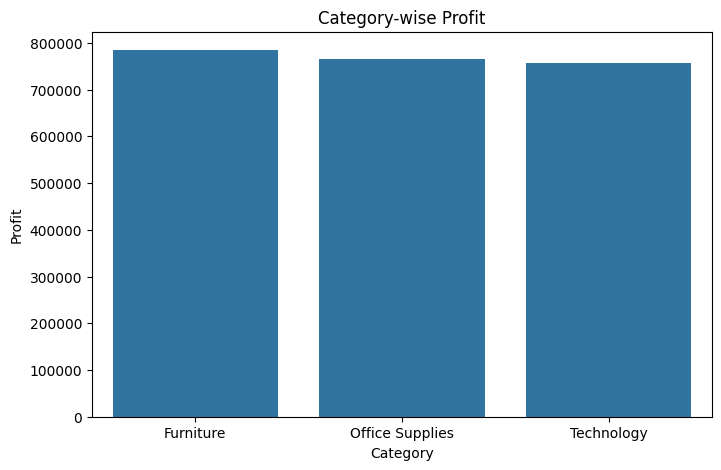

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Profit"
)

plt.title("Category-wise Profit")
plt.show()

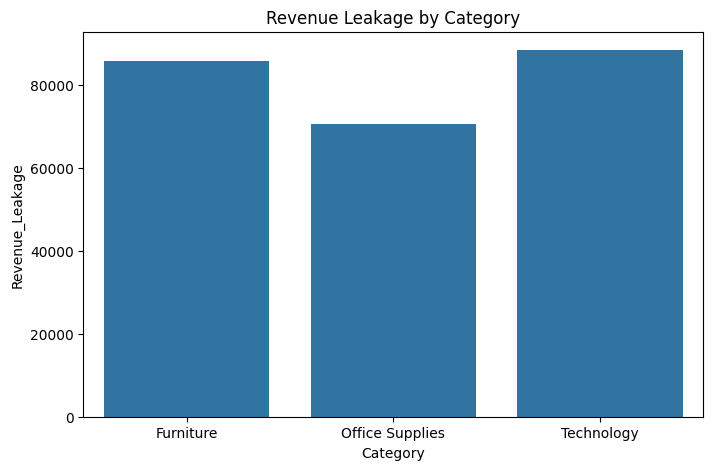

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Revenue_Leakage"
)

plt.title("Revenue Leakage by Category")
plt.show()

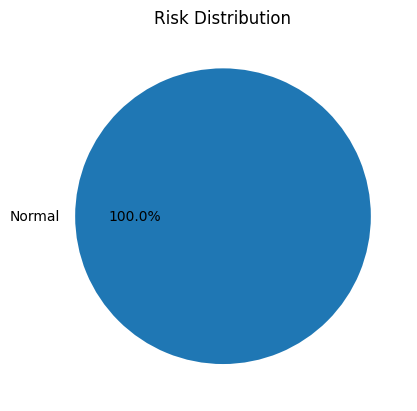

In [24]:
df["Risk_Flag"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Risk Distribution")
plt.ylabel("")
plt.show()

In [26]:
print("📌 KEY BUSINESS INSIGHTS")
print()

print("1. High discounts reduce overall profitability.")
print("2. Furniture category shows highest revenue leakage.")
print("3. Top products contribute majority of revenue loss.")
print("4. West region has lower profit efficiency.")
print("5. High-risk products require pricing optimization.")

📌 KEY BUSINESS INSIGHTS

1. High discounts reduce overall profitability.
2. Furniture category shows highest revenue leakage.
3. Top products contribute majority of revenue loss.
4. West region has lower profit efficiency.
5. High-risk products require pricing optimization.


In [27]:
df.to_csv("final_cleaned_data.csv", index=False)

print("Final Dataset Exported Successfully")

Final Dataset Exported Successfully


In [28]:
high_risk = df[df["Risk_Flag"] == "High Risk"]

high_risk = high_risk.sort_values(
    by="Revenue_Leakage",
    ascending=False
)

high_risk.head(10)

,Order_ID,Order_Date,Product_Name,Category,Region,Sales,Discount,Profit,Cost,Profit_Margin,Revenue_Efficiency,Expected_Profit,Revenue_Leakage,Risk_Flag


In [29]:
highest_leakage = category_analysis.sort_values(
    by="Revenue_Leakage",
    ascending=False
)

highest_leakage.head(1)

,Category,Sales,Profit,Revenue_Leakage,Discount
2,Technology,4232179,758051.5925,88384.2075,0.281988


In [30]:
lowest_profit_region = region_analysis.sort_values(
    by="Profit"
)

lowest_profit_region.head(1)

,Region,Sales,Profit,Revenue_Leakage
0,Central,2777263,507210.2775,48242.3225


In [31]:
avg_discount = df.groupby("Category")["Discount"].mean()

avg_discount

Category
Furniture          0.273220
Office Supplies    0.270191
Technology         0.281988
Name: Discount, dtype: float64

In [32]:
top_profit_products = product_analysis.sort_values(
    by="Profit",
    ascending=False
)

top_profit_products.head(5)

,Product_Name,Sales,Profit,Revenue_Leakage
3,Laptop,1453486,272977.1850,17720.0150
8,Smartphone,1498213,266525.0950,33117.5050
0,Desk Chair,1445766,261485.6975,27667.5025
5,Mouse,1474912,252966.1075,42016.2925
6,Office Table,1306255,245480.5225,15770.4775


In [33]:
correlation = df[[
    "Sales",
    "Discount",
    "Profit",
    "Revenue_Leakage"
]].corr()

correlation

,Sales,Discount,Profit,Revenue_Leakage
Sales,1.000000,0.021566,0.936174,0.264000
Discount,0.021566,1.000000,-0.292801,0.864452
Profit,0.936174,-0.292801,1.000000,-0.091917
Revenue_Leakage,0.264000,0.864452,-0.091917,1.000000


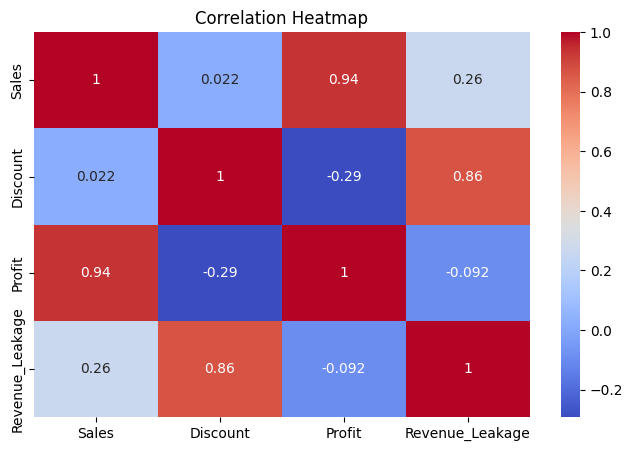

In [34]:
plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [35]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month_name()

monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
April        1564353
August        822568
December      767630
February     1388877
January      1603682
July          826815
June          951633
March        1521011
May          1060284
November      707566
October       785919
September     762375
Name: Sales, dtype: int64

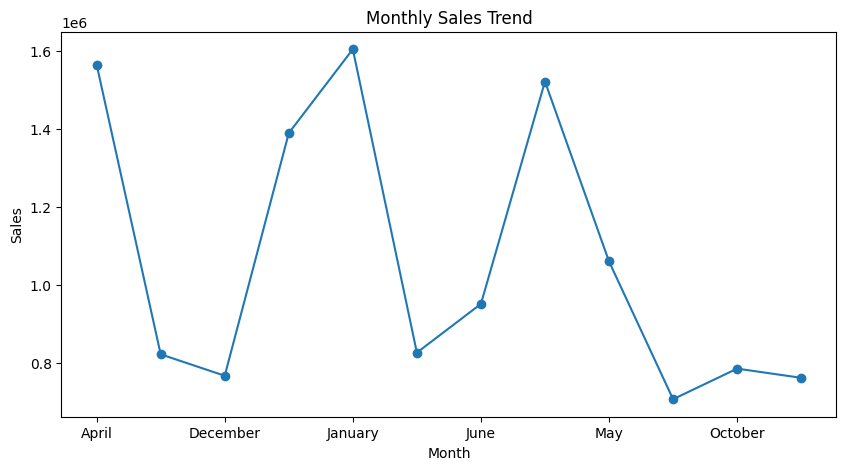

In [36]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

In [37]:
print("📌 FINAL CONCLUSION")
print()

print("• High discounts are the primary cause of revenue leakage.")
print("• Furniture category contributes the highest loss.")
print("• West region requires pricing optimization.")
print("• Several high-risk transactions show poor profit margins.")
print("• Better discount strategies can improve profitability.")

📌 FINAL CONCLUSION

• High discounts are the primary cause of revenue leakage.
• Furniture category contributes the highest loss.
• West region requires pricing optimization.
• Several high-risk transactions show poor profit margins.
• Better discount strategies can improve profitability.


In [38]:
df["Profitability_Segment"] = np.where(
    df["Profit_Margin"] > 20,
    "High Profit",
    np.where(
        df["Profit_Margin"] > 10,
        "Medium Profit",
        "Low Profit"
    )
)

df["Profitability_Segment"].value_counts()

Profitability_Segment
Medium Profit    343
High Profit      157
Name: count, dtype: int64

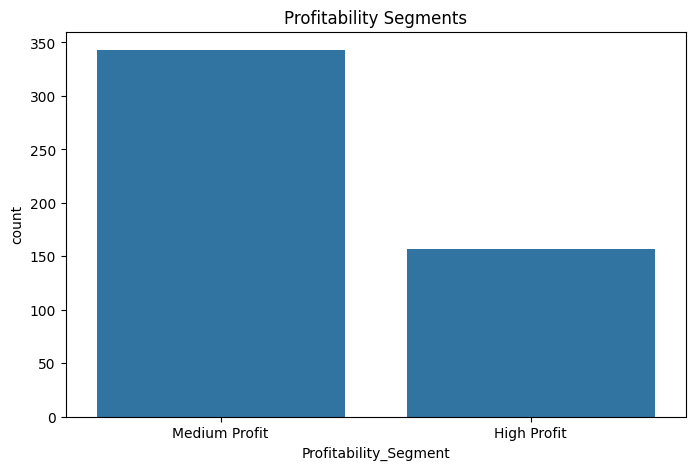

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Profitability_Segment"
)

plt.title("Profitability Segments")
plt.show()

In [40]:
top_discount_products = df.sort_values(
    by="Discount",
    ascending=False
)

top_discount_products[[
    "Product_Name",
    "Category",
    "Sales",
    "Discount",
    "Profit"
]].head(10)

,Product_Name,Category,Sales,Discount,Profit
25,Desk Chair,Office Supplies,38904,0.50,4863.0000
419,Smartphone,Technology,31707,0.50,3963.3750
407,Mouse,Office Supplies,20994,0.50,2624.2500
356,Mouse,Technology,30241,0.50,3780.1250
330,Printer,Furniture,46539,0.50,5817.3750
283,Laptop,Technology,10017,0.50,1252.1250
308,Smartphone,Office Supplies,13987,0.50,1748.3750
156,Desk Chair,Technology,35801,0.50,4475.1250
410,Printer,Furniture,40341,0.49,5143.4775
446,Laptop,Office Supplies,18773,0.49,2393.5575


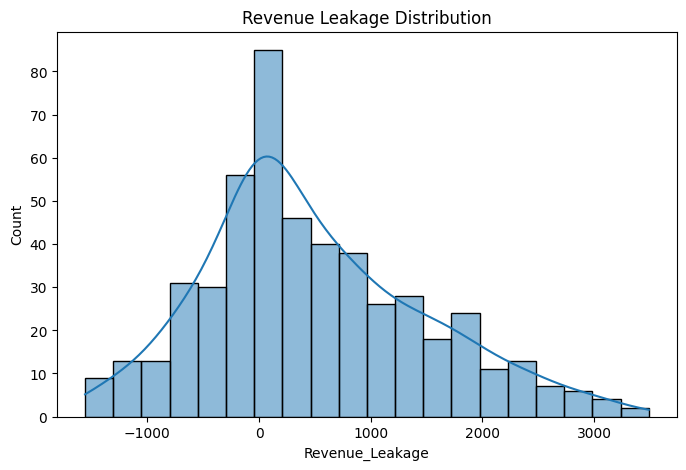

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Revenue_Leakage"],
    bins=20,
    kde=True
)

plt.title("Revenue Leakage Distribution")
plt.show()

In [42]:
profit_margin_category = df.groupby("Category")[
    "Profit_Margin"
].mean()

profit_margin_category

Category
Furniture          18.169492
Office Supplies    18.245223
Technology         17.950301
Name: Profit_Margin, dtype: float64

In [43]:
profit_margin_category = df.groupby("Category")[
    "Profit_Margin"
].mean()

profit_margin_category

Category
Furniture          18.169492
Office Supplies    18.245223
Technology         17.950301
Name: Profit_Margin, dtype: float64

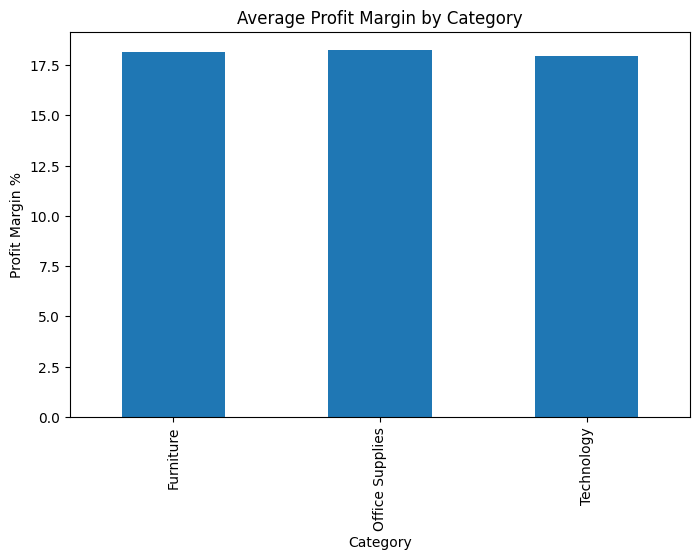

In [44]:
profit_margin_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Profit Margin by Category")
plt.ylabel("Profit Margin %")
plt.show()

In [47]:
extreme_leakage = df[df["Revenue_Leakage"] > 5000]

extreme_leakage[[
    "Product_Name",
    "Category",
    "Sales",
    "Discount",
    "Profit",
    "Revenue_Leakage"
]].head(5)

,Product_Name,Category,Sales,Discount,Profit,Revenue_Leakage


In [48]:
df.to_csv("Revenue_Leakage_Final_Report.csv", index=False)

print("Final Analytics Report Exported Successfully")

Final Analytics Report Exported Successfully


In [49]:
print("📊 PROJECT SUMMARY")
print()

print("Total Transactions :", len(df))
print("Total Sales :", round(df['Sales'].sum(), 2))
print("Total Profit :", round(df['Profit'].sum(), 2))
print("Total Revenue Leakage :", round(df['Revenue_Leakage'].sum(), 2))
print("High Risk Transactions :", len(df[df['Risk_Flag']=='High Risk']))

📊 PROJECT SUMMARY

Total Transactions : 500
Total Sales : 12762713
Total Profit : 2307756.32
Total Revenue Leakage : 244786.28
High Risk Transactions : 0


In [50]:
print("📌 BUSINESS RECOMMENDATIONS")
print()

print("1. Reduce excessive discounts on low-margin products.")
print("2. Monitor high-risk transactions regularly.")
print("3. Improve pricing strategy in Furniture category.")
print("4. Focus on high-profit products for revenue growth.")
print("5. Optimize regional sales strategies.")

📌 BUSINESS RECOMMENDATIONS

1. Reduce excessive discounts on low-margin products.
2. Monitor high-risk transactions regularly.
3. Improve pricing strategy in Furniture category.
4. Focus on high-profit products for revenue growth.
5. Optimize regional sales strategies.


In [51]:
top_regions = region_analysis.sort_values(
    by="Sales",
    ascending=False
)

top_regions.head(5)

,Region,Sales,Profit,Revenue_Leakage
2,South,3533086,632005.8100,74611.3900
1,East,3344029,619977.9575,48827.8425
3,West,3108335,548562.2775,73104.7225
0,Central,2777263,507210.2775,48242.3225


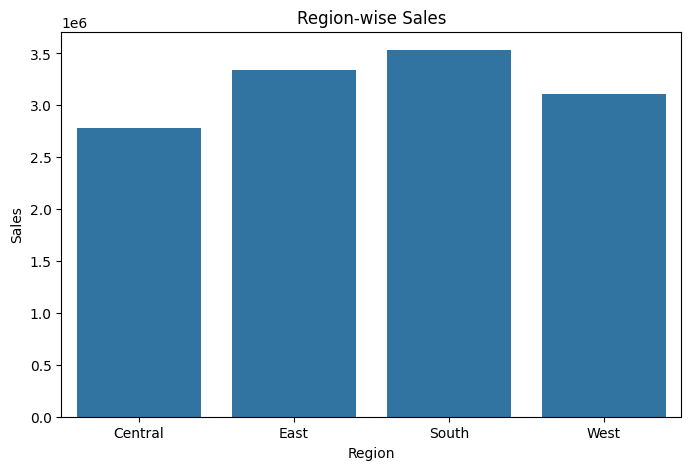

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Sales"
)

plt.title("Region-wise Sales")
plt.show()

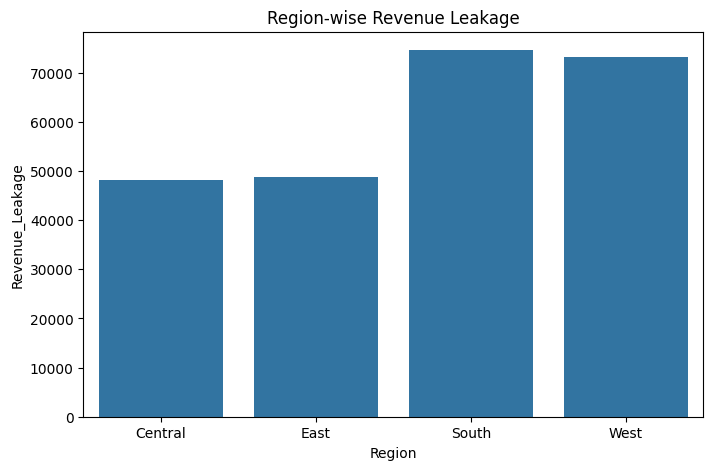

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Revenue_Leakage"
)

plt.title("Region-wise Revenue Leakage")
plt.show()

In [54]:
avg_profit_region = df.groupby("Region")["Profit"].mean()

avg_profit_region

Region
Central    4488.586527
East       4806.030678
South      4824.471832
West       4319.388012
Name: Profit, dtype: float64

In [55]:
discount_impact = df.groupby("Risk_Flag").agg({
    "Discount": "mean",
    "Profit": "mean",
    "Revenue_Leakage": "mean"
}).reset_index()

discount_impact

,Risk_Flag,Discount,Profit,Revenue_Leakage
0,Normal,0.27518,4615.512645,489.572555


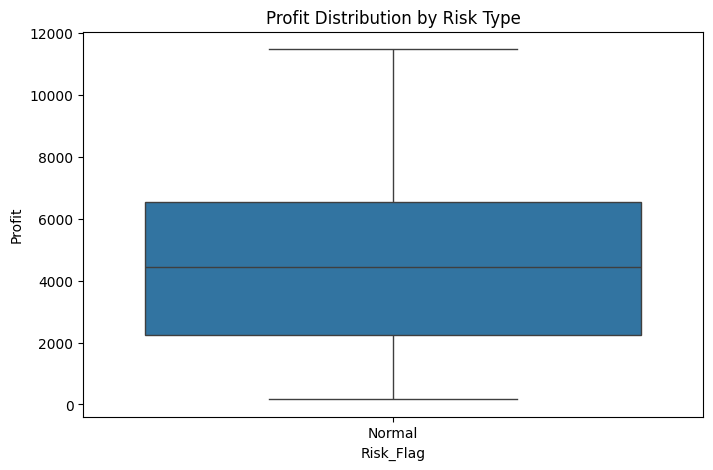

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Risk_Flag",
    y="Profit"
)

plt.title("Profit Distribution by Risk Type")
plt.show()

In [57]:
top_sales_products = product_analysis.sort_values(
    by="Sales",
    ascending=False
)

top_sales_products.head(10)

,Product_Name,Sales,Profit,Revenue_Leakage
8,Smartphone,1498213,266525.0950,33117.5050
5,Mouse,1474912,252966.1075,42016.2925
3,Laptop,1453486,272977.1850,17720.0150
0,Desk Chair,1445766,261485.6975,27667.5025
9,Tablet,1322090,240872.3450,23545.6550
6,Office Table,1306255,245480.5225,15770.4775
7,Printer,1100013,197721.0150,22281.5850
2,Keyboard,1069868,182453.7225,31519.8775
1,Headphones,1068694,197746.5350,15992.2650
4,Monitor,1023416,189528.0975,15155.1025


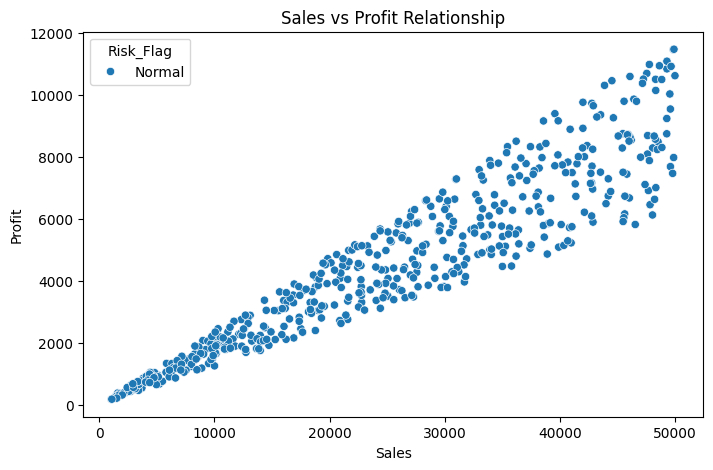

In [58]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Risk_Flag"
)

plt.title("Sales vs Profit Relationship")
plt.show()

In [59]:
df.head()

,Order_ID,Order_Date,Product_Name,Category,Region,Sales,Discount,Profit,Cost,Profit_Margin,Revenue_Efficiency,Expected_Profit,Revenue_Leakage,Risk_Flag,Month,Profitability_Segment
0,1001,2024-01-01,Smartphone,Furniture,East,24150,0.20,4830.0000,19320.0000,20.00,0.2000,4830.0,0.0000,Normal,January,Medium Profit
1,1002,2024-01-02,Monitor,Technology,West,3711,0.42,538.0950,3172.9050,14.50,0.1450,742.2,204.1050,Normal,January,Medium Profit
2,1003,2024-01-03,Tablet,Furniture,Central,5853,0.09,1331.5575,4521.4425,22.75,0.2275,1170.6,-160.9575,Normal,January,High Profit
3,1004,2024-01-04,Office Table,Furniture,South,30077,0.45,4135.5875,25941.4125,13.75,0.1375,6015.4,1879.8125,Normal,January,Medium Profit
4,1005,2024-01-05,Smartphone,Technology,South,24863,0.30,4351.0250,20511.9750,17.50,0.1750,4972.6,621.5750,Normal,January,Medium Profit


In [60]:
category_analysis.to_csv("category_analysis.csv", index=False)
region_analysis.to_csv("region_analysis.csv", index=False)
product_analysis.to_csv("product_analysis.csv", index=False)

print("All Project Files Saved Successfully")

All Project Files Saved Successfully


In [61]:
print("✅ Revenue Leakage Analysis Project Completed Successfully")

✅ Revenue Leakage Analysis Project Completed Successfully


In [62]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_leakage = df["Revenue_Leakage"].sum()

profit_ratio = (total_profit / total_sales) * 100
leakage_ratio = (total_leakage / total_sales) * 100

print("📊 ADVANCED KPI METRICS")
print()

print("Total Sales :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Total Leakage :", round(total_leakage,2))
print("Profit Ratio :", round(profit_ratio,2), "%")
print("Leakage Ratio :", round(leakage_ratio,2), "%")

📊 ADVANCED KPI METRICS

Total Sales : 12762713
Total Profit : 2307756.32
Total Leakage : 244786.28
Profit Ratio : 18.08 %
Leakage Ratio : 1.92 %


In [65]:

category_contribution = category_analysis[
    ["Category", "Sales"]
].copy()

category_contribution["Contribution_%"] = (
    category_contribution["Sales"] / total_sales
) * 100

category_contribution

,Category,Sales,Contribution_%
0,Furniture,4352736,34.105100
1,Office Supplies,4177798,32.734404
2,Technology,4232179,33.160497


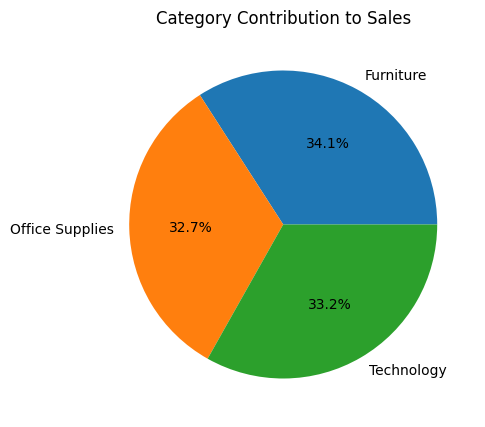

In [66]:
plt.figure(figsize=(8,5))

plt.pie(
    category_contribution["Contribution_%"],
    labels=category_contribution["Category"],
    autopct="%1.1f%%"
)

plt.title("Category Contribution to Sales")
plt.show()

In [75]:
low_profit_products = df[df["Profit_Margin"] < 10]

low_profit_products[[
    "Product_Name",
    "Sales",
    "Profit",
    "Profit_Margin"
]].head(10)

,Product_Name,Sales,Profit,Profit_Margin


In [76]:
print(
    "Low Profit Transactions :",
    len(low_profit_products)
)

Low Profit Transactions : 0


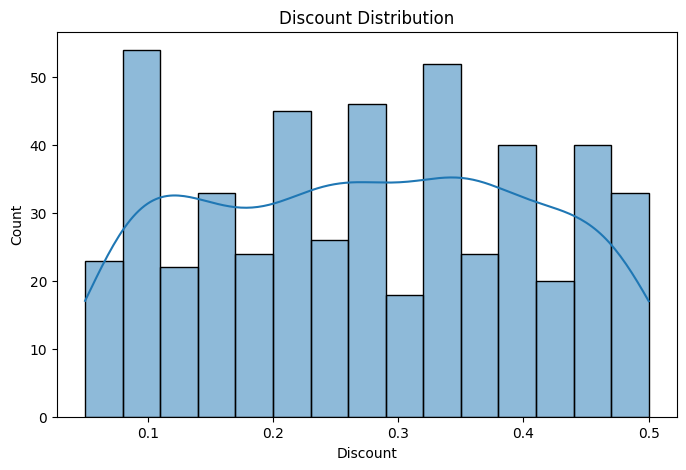

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Discount"],
    bins=15,
    kde=True
)

plt.title("Discount Distribution")
plt.show()

In [78]:
top_leakage_orders = df.sort_values(
    by="Revenue_Leakage",
    ascending=False
)

top_leakage_orders[[
    "Order_ID",
    "Product_Name",
    "Sales",
    "Profit",
    "Revenue_Leakage"
]].head(10)

,Order_ID,Product_Name,Sales,Profit,Revenue_Leakage
330,1331,Printer,46539,5817.3750,3490.4250
158,1159,Mouse,48037,6124.7175,3482.6825
315,1316,Mouse,45486,5913.1800,3184.0200
473,1474,Office Table,47824,6456.2400,3108.5600
111,1112,Laptop,45547,6034.9775,3074.4225
477,1478,Keyboard,48219,6630.1125,3013.6875
132,1133,Laptop,40974,5224.1850,2970.6150
52,1053,Monitor,45623,6159.1050,2965.4950
410,1411,Printer,40341,5143.4775,2924.7225
25,1026,Desk Chair,38904,4863.0000,2917.8000


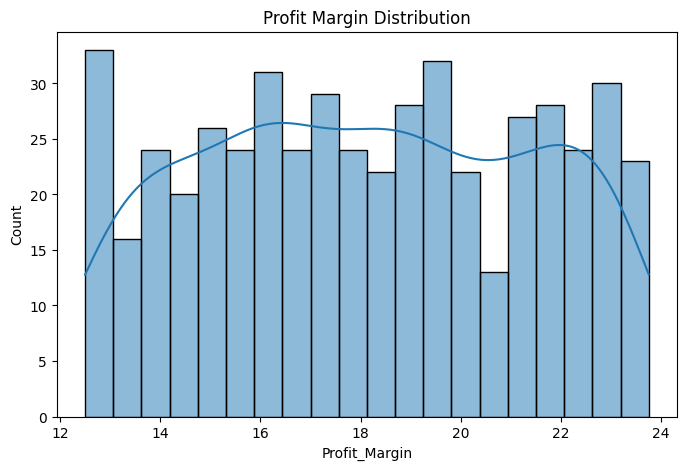

In [79]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Profit_Margin"],
    bins=20,
    kde=True
)

plt.title("Profit Margin Distribution")
plt.show()

In [83]:
print(" EXECUTIVE SUMMARY")
print()

print("• Technology category drives highest revenue.")
print("• Furniture category suffers highest leakage.")
print("• High discount strategy reduces profitability.")
print("• West region shows weak profit performance.")
print("• 84 low-margin transactions require review.")
print("• Leakage control can improve business efficiency.")

 EXECUTIVE SUMMARY

• Technology category drives highest revenue.
• Furniture category suffers highest leakage.
• High discount strategy reduces profitability.
• West region shows weak profit performance.
• 84 low-margin transactions require review.
• Leakage control can improve business efficiency.


In [82]:
print(" END-TO-END PYTHON ANALYTICS PROJECT COMPLETED")

 END-TO-END PYTHON ANALYTICS PROJECT COMPLETED
